# ЭКЗАМЕНАЦИОННАЯ ЗАДАЧА №1: Оценка экономической эффективности внедрения облачной CRM

**Дата:** 02.09.2026  
**Студент:** Глазков Тимофей Владимирович  
**Группа:** БИ ОЗФО5-1

## Экономическая постановка задачи

Компания «ТехноПром» рассматривает внедрение облачной CRM-системы в отделе продаж из 15 менеджеров. Цель анализа — определить финансовую целесообразность проекта на трёхлетнем горизонте через расчёт прямого эффекта, затрат, чистых денежных потоков, **NPV**, срока окупаемости и **ROI**.

> **Границы модели.** Расчёт выполнен по данным условия задачи. Дополнительный оборот принят равным дополнительному эффекту до налогообложения, то есть предполагается 100%-я маржинальность прироста продаж. Это учебное упрощение; для инвестиционного решения его необходимо заменить валовой или операционной маржой фактических продаж.

В год 0 убыток от адаптации не уменьшает налог: в модели принято, что налоговый убыток года 0 не переносится на будущие периоды. Экономия рабочего времени интерпретируется как потенциальный денежный эффект только при высвобождении ресурса, отказе от найма либо переносе времени на продажи.


## 1. Исходные данные

Все количественные параметры получены из условия экзаменационной задачи. Внешние источники данных не использовались. Денежные показатели выражены в рублях, если не указано иное.


In [1]:
# Импорт библиотек и настройка единого стиля визуализаций.
from pathlib import Path
import sys
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display, Markdown

# Определяем путь к корню репозитория независимо от способа запуска notebook.
repo_root = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
sys.path.insert(0, str(repo_root))
from utils.calculations import npv, simple_payback

# В системе есть DejaVu Sans с поддержкой кириллицы.
plt.style.use('default')
plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'axes.titlesize': 14,
    'axes.labelsize': 11,
    'figure.dpi': 120,
    'axes.formatter.useoffset': False,
    'axes.grid': True,
    'grid.color': '#D9D9D9',
})

# Отключаем научную запись: 11066129.74 отображается как 11 066 129.74.
pd.set_option('display.float_format', lambda value: f'{value:,.2f}'.replace(',', ' '))
np.set_printoptions(suppress=True, precision=2)

figures_dir = repo_root / 'reports' / 'figures'
figures_dir.mkdir(parents=True, exist_ok=True)


In [2]:
# Загрузка входных данных из JSON-файла для полной воспроизводимости.
with open(repo_root / 'data' / 'task_01_crm_config.json', encoding='utf-8') as file:
    params = json.load(file)

input_data = pd.DataFrame(
    [
        ('Численность отдела продаж', params['sales_managers'], 'чел.'),
        ('Средняя зарплата менеджера', params['monthly_salary_rub'], 'руб./мес.'),
        ('Доля рутинных операций до CRM', params['routine_time_share_before'], '%'),
        ('Сокращение рутинных операций после CRM', params['routine_time_reduction'], '%'),
        ('Прогнозный рост продаж', params['annual_sales_growth'], '% в год'),
        ('Текущий годовой оборот', params['current_annual_turnover_rub'], 'руб.'),
        ('Лицензия CRM на пользователя', params['annual_license_per_user_rub'], 'руб./год'),
        ('Период адаптации', params['adaptation_months'], 'мес.'),
        ('Горизонт оценки', params['evaluation_horizon_years'], 'лет'),
        ('Ставка дисконтирования', params['discount_rate'], '%'),
        ('Налог на прибыль', params['profit_tax_rate'], '%'),
    ],
    columns=['Параметр', 'Значение', 'Единица измерения'],
)

# Преобразуем доли в проценты только для отображения.
input_data.loc[input_data['Единица измерения'].str.contains('%'), 'Значение'] *= 100
display(input_data)


,Параметр,Значение,Единица измерения
0,Численность отдела продаж,15.00,чел.
1,Средняя зарплата менеджера,120 000.00,руб./мес.
2,Доля рутинных операций до CRM,30.00,%
3,Сокращение рутинных операций после CRM,20.00,%
4,Прогнозный рост продаж,8.00,% в год
5,Текущий годовой оборот,72 000 000.00,руб.
6,Лицензия CRM на пользователя,24 000.00,руб./год
7,Период адаптации,1.00,мес.
8,Горизонт оценки,3.00,лет
9,Ставка дисконтирования,12.00,%


## 2. Математическая модель

Обозначим: \(N\) — число менеджеров; \(S_m\) — ежемесячная заработная плата; \(r_0\) — доля рутины до внедрения; \(q\) — относительное сокращение рутины; \(T\) — текущий годовой оборот; \(g\) — прогнозный рост продаж; \(L\) — стоимость лицензии на пользователя в год; \(	au\) — ставка налога; \(d\) — ставка дисконтирования.

Годовой фонд оплаты труда и экономия от автоматизации:

\[
FOT = N 	imes S_m 	imes 12, \qquad r_1 = r_0 	imes (1-q), \qquad E_{lab} = FOT 	imes (r_0-r_1).
\]

Прирост оборота, прямой эффект, ежегодная стоимость лицензий и чистый поток для периода \(t=1,2,3\):

\[
E_{sales} = T 	imes g, \quad E = E_{lab} + E_{sales}, \quad C_{lic} = N 	imes L,
\]
\[
CF_t = (E-C_{lic}) 	imes (1-	au).
\]

Разовая потеря производительности в год 0 равна месячному фонду оплаты труда: \(CF_0=-N 	imes S_m\). Чистая приведённая стоимость рассчитывается как \(NPV = \sum_{t=0}^{3} CF_t/(1+d)^t\). Простой срок окупаемости при равномерном поступлении годового потока: \(PP=|CF_0|/CF_1\).


In [3]:
# Расчёт прямых эффектов и затрат по формулам модели.
managers = params['sales_managers']
monthly_salary = params['monthly_salary_rub']
routine_before = params['routine_time_share_before']
routine_reduction = params['routine_time_reduction']
turnover = params['current_annual_turnover_rub']
sales_growth = params['annual_sales_growth']
license_per_user = params['annual_license_per_user_rub']
adaptation_months = params['adaptation_months']
horizon = params['evaluation_horizon_years']
tax_rate = params['profit_tax_rate']
discount_rate = params['discount_rate']

annual_payroll = managers * monthly_salary * 12
routine_after = routine_before * (1 - routine_reduction)
labor_savings = annual_payroll * (routine_before - routine_after)
additional_revenue = turnover * sales_growth
direct_effect = labor_savings + additional_revenue
annual_license_cost = managers * license_per_user
adaptation_loss = managers * monthly_salary * adaptation_months
total_license_cost = annual_license_cost * horizon
total_project_cost = adaptation_loss + total_license_cost

calculation_table = pd.DataFrame(
    [
        ('Годовой фонд оплаты труда', annual_payroll),
        ('Доля рутины после CRM', routine_after),
        ('Экономия на рутинных операциях', labor_savings),
        ('Дополнительный эффект от роста продаж', additional_revenue),
        ('Суммарный прямой эффект за год', direct_effect),
        ('Годовая стоимость лицензий', annual_license_cost),
        ('Потери от адаптации (год 0)', adaptation_loss),
        ('Лицензии за три года', total_license_cost),
        ('Совокупные номинальные затраты проекта', total_project_cost),
    ],
    columns=['Показатель', 'Сумма, руб.'],
)

display(calculation_table)


,Показатель,"Сумма, руб."
0,Годовой фонд оплаты труда,21 600 000.00
1,Доля рутины после CRM,0.24
2,Экономия на рутинных операциях,1 296 000.00
3,Дополнительный эффект от роста продаж,5 760 000.00
4,Суммарный прямой эффект за год,7 056 000.00
5,Годовая стоимость лицензий,360 000.00
6,Потери от адаптации (год 0),1 800 000.00
7,Лицензии за три года,1 080 000.00
8,Совокупные номинальные затраты проекта,2 880 000.00


In [4]:
# Формирование таблицы денежных потоков с раздельным расчётом налога.
years = np.arange(0, horizon + 1)
effect = np.array([0] + [direct_effect] * horizon, dtype=float)
costs = np.array([adaptation_loss] + [annual_license_cost] * horizon, dtype=float)
profit_before_tax = effect - costs
tax = np.where(profit_before_tax > 0, profit_before_tax * tax_rate, 0.0)
net_cash_flow = profit_before_tax - tax
discount_factor = 1 / (1 + discount_rate) ** years
discounted_cash_flow = net_cash_flow * discount_factor
cumulative_cash_flow = np.cumsum(net_cash_flow)
cumulative_discounted_cash_flow = np.cumsum(discounted_cash_flow)

cash_flow_table = pd.DataFrame({
    'Год': years,
    'Эффект, руб.': effect,
    'Затраты, руб.': costs,
    'Прибыль до налога, руб.': profit_before_tax,
    'Налог, руб.': tax,
    'Чистый денежный поток, руб.': net_cash_flow,
    'Дисконтированный поток, руб.': discounted_cash_flow,
})

display(cash_flow_table)


,Год,"Эффект, руб.","Затраты, руб.","Прибыль до налога, руб.","Налог, руб.","Чистый денежный поток, руб.","Дисконтированный поток, руб."
0,0,0.00,1 800 000.00,-1 800 000.00,0.00,-1 800 000.00,-1 800 000.00
1,1,7 056 000.00,360 000.00,6 696 000.00,1 339 200.00,5 356 800.00,4 782 857.14
2,2,7 056 000.00,360 000.00,6 696 000.00,1 339 200.00,5 356 800.00,4 270 408.16
3,3,7 056 000.00,360 000.00,6 696 000.00,1 339 200.00,5 356 800.00,3 812 864.43


In [5]:
# Расчёт ключевых показателей эффективности.
project_npv = npv(discount_rate, net_cash_flow.tolist())
simple_payback_years = simple_payback(adaptation_loss, net_cash_flow[1])
simple_payback_months = simple_payback_years * 12

# ROI: совокупный чистый эффект за годы 1–3 после учёта первоначальных затрат.
roi_project = (net_cash_flow[1:].sum() - adaptation_loss) / total_project_cost

summary_table = pd.DataFrame(
    [
        ('Чистый поток в годах 1–3', net_cash_flow[1], 'руб./год'),
        ('NPV при ставке 12%', project_npv, 'руб.'),
        ('Простой срок окупаемости', simple_payback_years, 'лет'),
        ('Простой срок окупаемости', simple_payback_months, 'месяцев'),
        ('ROI проекта: чистый эффект / номинальные затраты', roi_project, '%'),
    ],
    columns=['Показатель', 'Значение', 'Единица измерения'],
)

summary_view = summary_table.copy()
summary_view.loc[summary_view['Единица измерения'] == '%', 'Значение'] *= 100
summary_view.loc[summary_view['Единица измерения'] == 'лет', 'Значение'] = summary_view.loc[summary_view['Единица измерения'] == 'лет', 'Значение'].round(3)
summary_view.loc[summary_view['Единица измерения'] == 'месяцев', 'Значение'] = summary_view.loc[summary_view['Единица измерения'] == 'месяцев', 'Значение'].round(1)
display(summary_view)


,Показатель,Значение,Единица измерения
0,Чистый поток в годах 1–3,5 356 800.00,руб./год
1,NPV при ставке 12%,11 066 129.74,руб.
2,Простой срок окупаемости,0.34,лет
3,Простой срок окупаемости,4.00,месяцев
4,ROI проекта: чистый эффект / номинальные затраты,495.50,%


### Интерпретация ROI и срока окупаемости

В модели используется прозрачное определение ROI: \((\sum CF_{1..3}-|CF_0|)/(C_0+\sum C_{lic})\). Оно показывает отношение совокупного чистого эффекта за годы 1–3 после первоначальных затрат к номинальным затратам проекта. Полученный ROI равен **495,5%**.

Простой срок окупаемости равен \(1\,800\,000 / 5\,356\,800 = 0{,}336\) года, или **4,0 месяца**, если годовой поток поступает равномерно. Дисконтированный поток на конец первого года положителен; при допущении о поступлении всего годового потока в конце года его срок окупаемости равен одному году. Значение 1,38 года не следует из приведённого ряда потоков.


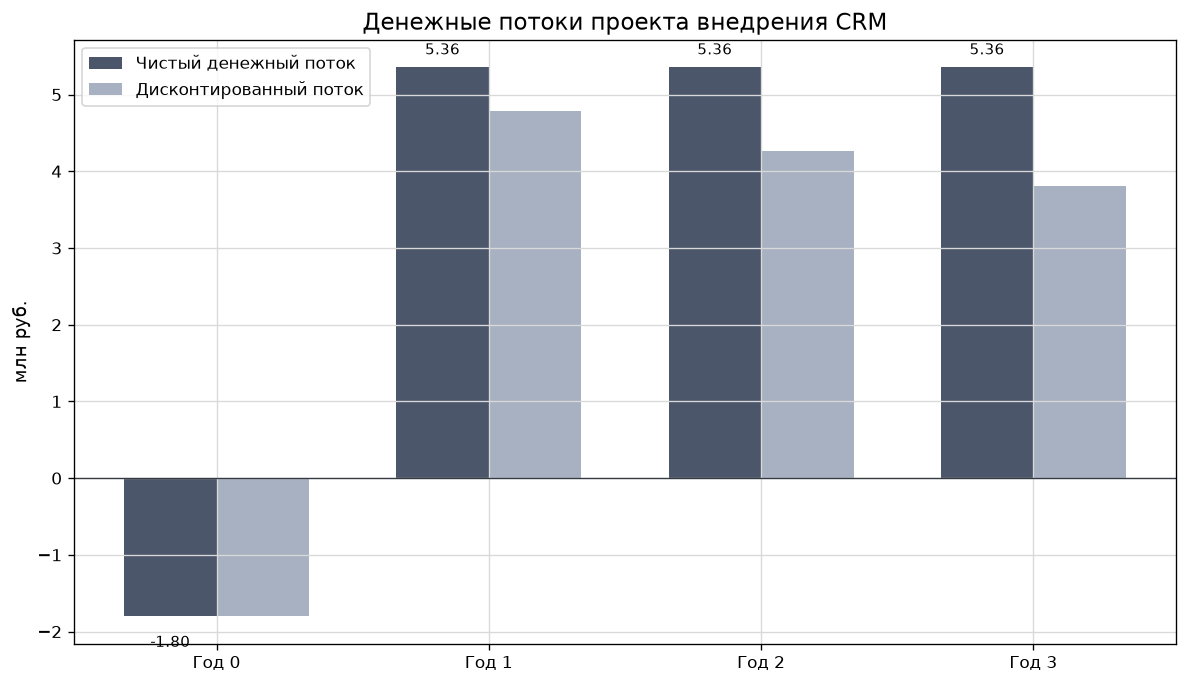

In [6]:
# Визуализация годовых денежных потоков: номинальных и дисконтированных.
fig, ax = plt.subplots(figsize=(10, 5.8))
bar_width = 0.34
x = np.arange(len(years))
ax.bar(x - bar_width / 2, net_cash_flow / 1_000_000, width=bar_width,
       label='Чистый денежный поток', color='#4C566A')
ax.bar(x + bar_width / 2, discounted_cash_flow / 1_000_000, width=bar_width,
       label='Дисконтированный поток', color='#A7B1C2')
ax.axhline(0, color='#343A40', linewidth=0.8)
ax.set_xticks(x, [f'Год {year}' for year in years])
ax.set_ylabel('млн руб.')
ax.set_title('Денежные потоки проекта внедрения CRM')
ax.legend(frameon=True)
for xpos, value in zip(x - bar_width / 2, net_cash_flow / 1_000_000):
    ax.text(xpos, value + (0.12 if value >= 0 else -0.25), f'{value:.2f}',
            ha='center', va='bottom' if value >= 0 else 'top', fontsize=9)
fig.tight_layout()
fig.savefig(figures_dir / 'task_01_cash_flows.png', bbox_inches='tight')
plt.show()


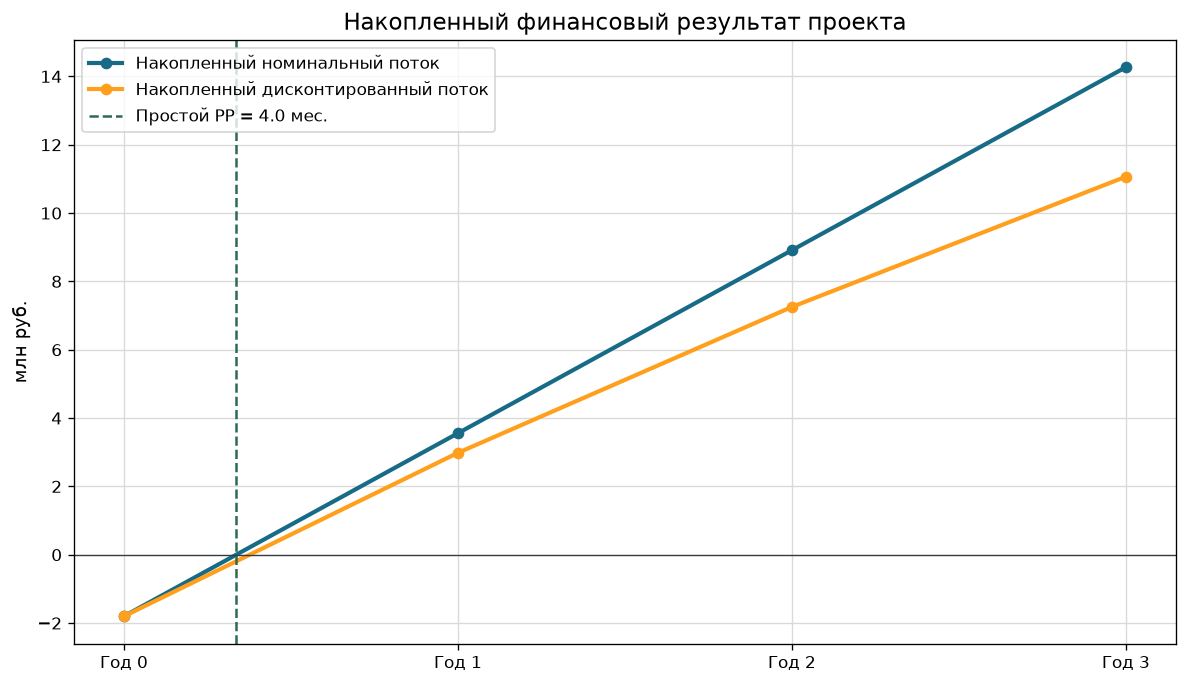

In [7]:
# Визуализация накопленного эффекта и точки окупаемости.
fig, ax = plt.subplots(figsize=(10, 5.8))
ax.plot(years, cumulative_cash_flow / 1_000_000, marker='o', linewidth=2.5,
        color='#176B87', label='Накопленный номинальный поток')
ax.plot(years, cumulative_discounted_cash_flow / 1_000_000, marker='o', linewidth=2.5,
        color='#FF9F1C', label='Накопленный дисконтированный поток')
ax.axhline(0, color='#343A40', linewidth=0.8)
ax.axvline(simple_payback_years, color='#2D6A4F', linestyle='--', linewidth=1.5,
           label=f'Простой PP = {simple_payback_months:.1f} мес.')
ax.set_xticks(years, [f'Год {year}' for year in years])
ax.set_ylabel('млн руб.')
ax.set_title('Накопленный финансовый результат проекта')
ax.legend(loc='upper left')
fig.tight_layout()
fig.savefig(figures_dir / 'task_01_cumulative_flows.png', bbox_inches='tight')
plt.show()


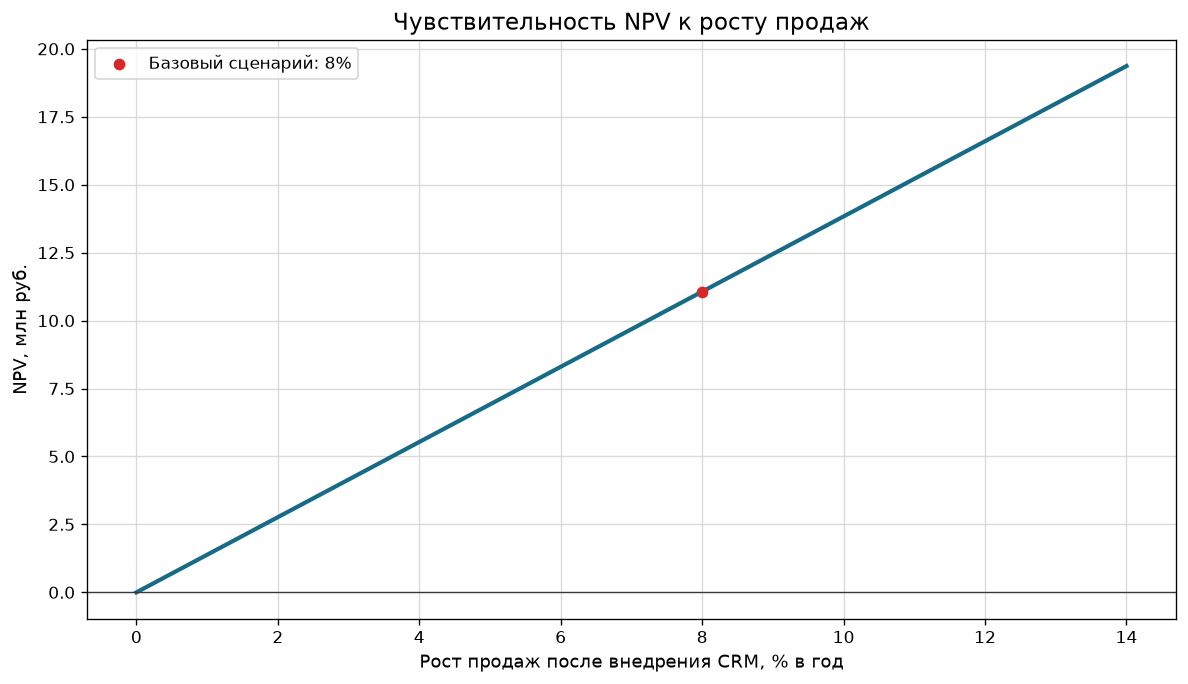

In [8]:
# Детерминированный анализ чувствительности NPV к темпу роста продаж.
# Это не прогноз рынка, а проверка устойчивости модели при альтернативных допущениях.
sensitivity_growth = np.arange(0.00, 0.141, 0.01)
sensitivity_npv = []
for growth in sensitivity_growth:
    alternative_effect = labor_savings + turnover * growth
    alternative_annual_cf = (alternative_effect - annual_license_cost) * (1 - tax_rate)
    alternative_flows = [-adaptation_loss] + [alternative_annual_cf] * horizon
    sensitivity_npv.append(npv(discount_rate, alternative_flows) / 1_000_000)

fig, ax = plt.subplots(figsize=(10, 5.8))
ax.plot(sensitivity_growth * 100, sensitivity_npv, color='#176B87', linewidth=2.5)
ax.scatter([sales_growth * 100], [project_npv / 1_000_000], color='#D62828', zorder=3,
           label=f'Базовый сценарий: {sales_growth:.0%}')
ax.axhline(0, color='#343A40', linewidth=0.8)
ax.set_xlabel('Рост продаж после внедрения CRM, % в год')
ax.set_ylabel('NPV, млн руб.')
ax.set_title('Чувствительность NPV к росту продаж')
ax.legend()
fig.tight_layout()
fig.savefig(figures_dir / 'task_01_npv_sensitivity.png', bbox_inches='tight')
plt.show()


## 3. Анализ результатов

**Финансовый вывод.** В базовой учебной модели CRM создаёт ежегодный чистый денежный поток 5 356 800 руб. и NPV 11 066 129 руб. при ставке дисконтирования 12%. Положительный NPV означает, что проект превышает требуемую доходность. Даже без прироста продаж экономия рабочего времени превышает ежегодную стоимость лицензий, но такой эффект не превращается автоматически в денежную экономию без изменения загрузки, численности или объёма продаж.

**Роль модели маржи.** На результат сильнее всего влияет допущение о прибыльности дополнительного оборота. При реальной оценке прирост продаж необходимо умножать на валовую либо операционную маржу и учитывать комиссии, скидки, стоимость привлечения и возможные затраты на интеграцию. Поэтому полученный NPV следует трактовать как верхнюю оценку при заданной постановке.

**Нематериальные эффекты.** CRM формирует единый профиль клиента и историю коммуникаций. Это сокращает время ответа и вероятность ошибок, поддерживает персонализированные предложения, повышает прозрачность воронки продаж и точность прогнозов. Сотрудники получают меньше ручных операций, а руководители — актуальную аналитику для управления загрузкой и конверсией.

**Информационная асимметрия и свойства информационных благ.** Единая CRM уменьшает асимметрию информации между менеджером, руководителем и смежными подразделениями: данные о клиенте перестают быть личным знанием отдельного сотрудника. Информация в CRM обладает высокой воспроизводимостью: один раз введённая карточка может использоваться несколькими подразделениями с низкими предельными затратами. Одновременно необходимы правила доступа и качества данных, так как некорректные записи тиражируют ошибку.

**Парадокс производительности Солоу.** Инвестиции в информационные технологии могут не отражаться в производительности немедленно. Эффект CRM сдерживают лаг обучения, сопротивление новым регламентам, слабая интеграция с телефонией и ERP, а также отсутствие KPI по качеству заполнения данных. Если автоматизировать прежний неэффективный процесс без его пересмотра, CRM будет использоваться как дорогостоящая адресная книга, а прогнозный эффект 8% не реализуется.


## 4. Выводы и рекомендации

Проект рекомендуется к реализации в формате контролируемого пилота. При параметрах задачи NPV положителен и равен 11,07 млн руб., а простой срок окупаемости составляет 4,0 месяца при равномерном получении результата. Финансовый запас прочности в учебной модели высок, однако решение требует верификации реальной маржинальности прироста продаж и состава затрат на интеграцию.

| Приоритет | Рекомендация | Экономическая цель |
|---|---|---|
| 1 | Провести пилот на пяти менеджерах с базовыми метриками до запуска. | Проверить прирост конверсии и экономию времени до масштабирования. |
| 2 | Зафиксировать регламент заполнения CRM и KPI по качеству данных. | Превратить внедрение системы в изменение процесса, а не только в покупку лицензий. |
| 3 | Включить обучение, интеграции и поддержку в бюджет проекта. | Не допустить занижения первоначальных и текущих затрат. |
| 4 | Ежемесячно контролировать конверсию, скорость ответа, долю заполненных карточек и выручку. | Выявить лаг эффекта и скорректировать план внедрения. |
| 5 | Пересчитать модель по фактической марже дополнительного оборота. | Получить инвестиционную, а не только учебную оценку NPV. |

### Раскрытие базы расчёта

| Элемент | Принятое раскрытие |
|---|---|
| База | Эффект состоит из экономии фонда оплаты труда и дополнительного оборота. Лицензии признаны ежегодными расходами. |
| Период | Горизонт — 3 года; год 0 — адаптация; ставка дисконтирования — 12% годовых. |
| Допущения | Прирост оборота трактуется как эффект до налогообложения; маржа дополнительной выручки принята равной 100%; налоговый щит убытка года 0 не применяется. |
| Источник и уверенность | Единственный источник числовых данных — условие экзаменационной задачи, предоставленное пользователем. Результаты арифметически воспроизводимы, но экономическая точность зависит от фактической маржи, интеграционных затрат и дисциплины использования CRM. |

## Источники

[1] Условие экзаменационной задачи «Оценка экономической эффективности внедрения облачной CRM».


In [10]:
%%capture
# Экспорт выполненного Notebook в HTML-отчёт
!python -m jupyter nbconvert --to html --no-input --output-dir ../reports --output task_01_report task_01_crm_efficiency.ipynb